### DataSet and Import

In [8]:
#기초
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

#Encoder
from sklearn.preprocessing import OneHotEncoder

# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Encoder
from sklearn.preprocessing import LabelEncoder

#국어
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#joblib
import joblib


### Data Loading

In [9]:
df = pd.read_csv("./dataset/HR_comma_sep.csv")

### 데이터 준비

In [10]:
# Departments' 열 이름 수정 (공백 제거)
df.columns = df.columns.str.strip()
#범주형 변수('Departments', 'salary')를 One-Hot Encoding으로 변환
df = pd.get_dummies(df, columns=['Departments', 'salary'], drop_first=True)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


### 처리

In [11]:
encoder = {}

for col in df:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoder[col] = le

# 1. Param Grid 설정
param_grid = {
    'n_estimators': [50, 100, 200],  # 트리의 개수
    'max_depth': [4, 6, 8],       # 트리의 최대 깊이
    'min_samples_split': [2, 4],  # 노드를 분할하기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2]    # 리프 노드에 있어야 하는 최소 샘플 수
}

# 2. 모델 및 GridSearchCV 초기화 (분류 모델 사용)
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy')

# 3. Feature Selection & Target 설정 (선택하신 특성만 반영)
selected_features = ['satisfaction_level', 'number_project', 'time_spend_company']
X = df[selected_features]
y = df['left']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 4. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

# 5. GridSearchCV 실행 (자동으로 최적의 파라미터 학습)
grid_search.fit(X_train, y_train)

# 6. 최적의 모델 추출
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 7. 예측 및 평가 (Classification Metrics 사용)
y_pred = best_model.predict(X_test)



Best Parameters: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


교차 검증 점수:
평균 정확도: 0.9656 (+/- 0.0163)

분류 리포트:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2294
           1       0.96      0.90      0.93       706

    accuracy                           0.97      3000
   macro avg       0.96      0.94      0.95      3000
weighted avg       0.97      0.97      0.97      3000



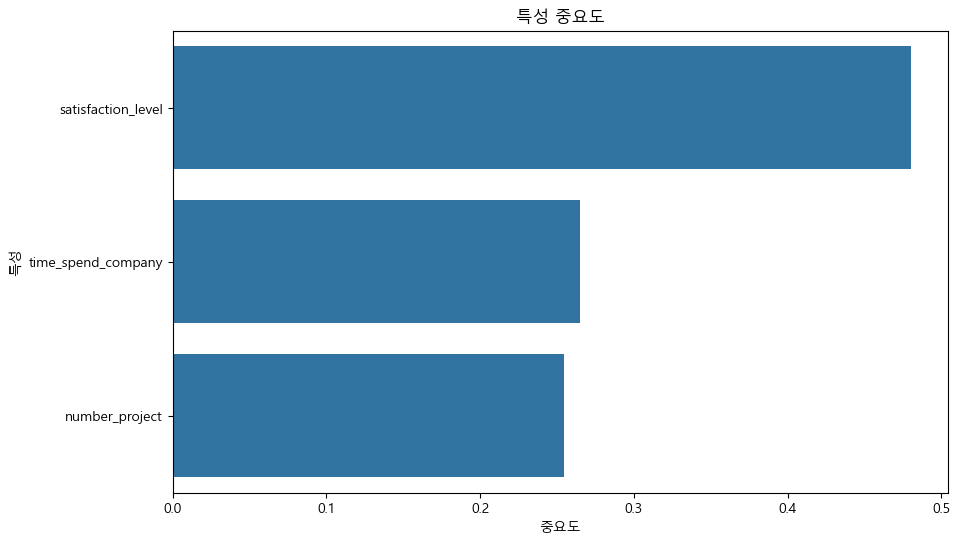

In [12]:
# 교차 검증 수행
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5)

# 특성 중요도 계산  (cf. permutation_importance : 다른 피처에 영향을 주는 정도를 측정)
feature_importance = pd.DataFrame({
    '특성': X.columns,
    '중요도': best_model.feature_importances_
}).sort_values('중요도', ascending=False)

# 결과 출력
print("교차 검증 점수:")
print(f"평균 정확도: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("\n분류 리포트:")
print(classification_report(y_test, y_pred))

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='중요도', y='특성', data=feature_importance)
plt.title('특성 중요도')
plt.show()

### 혼동 행렬 시각화

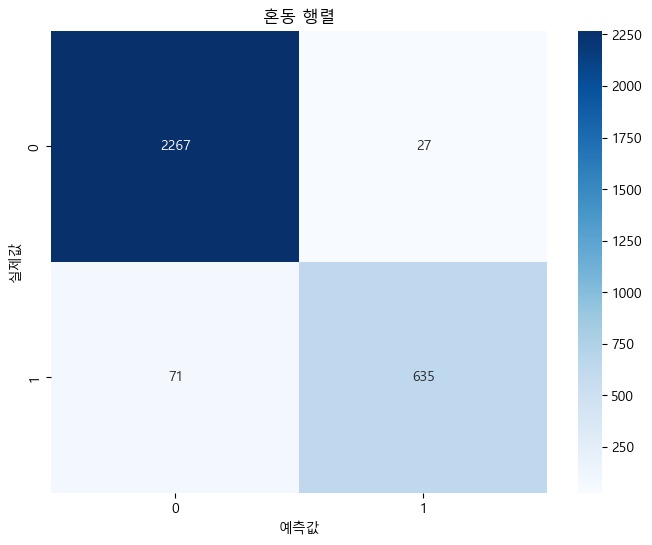

In [13]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('혼동 행렬')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.show()

### 모델 생성

In [14]:
joblib.dump(best_model, "modeljunghoKim.pkl")
joblib.dump(encoder, "encoderjunghoKim.pkl")
joblib.dump(scaler, "scalerjunghoKim.pkl")
print("\n모델 저장 완료!")


모델 저장 완료!
